# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\leha_\\Documents\\vscode-projects\\football-players-data\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\leha_\\Documents\\vscode-projects\\football-players-data'

# Section 1

Section 1 content

In [4]:
# import libarries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style('whitegrid')

---

# Section 2

Data Visualisation - load the cleaned data 

In [5]:
# load the cleaned data
df = pd.read_csv('DataSet/CleanData/cleaned_data.csv')
df.head()

,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,wage_euro,...,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),body_type,release_clause_euro,national_team,defense_attributes,attack_attributes,passing_attributes,pace_attributes
0,Lionel Andrés Messi Cuccittini,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,565000.0,...,5,4,4,Messi,226500000.0,Argentina,45.571429,85.571429,93.0,84.166667
1,Christian Dannemann Eriksen,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,205000.0,...,3,5,4,Lean,133800000.0,Denmark,55.142857,76.714286,88.6,75.333333
2,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,255000.0,...,4,4,5,Normal,144200000.0,France,73.285714,81.571429,85.8,77.166667
3,Lorenzo Insigne,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,165000.0,...,3,4,4,Normal,105400000.0,Italy,40.571429,72.857143,85.3,82.500000
4,Virgil van Dijk,27,193.04,92.1,CB,Netherlands,88,90,59500000.0,215000.0,...,3,3,2,Normal,114500000.0,Netherlands,87.428571,61.142857,69.6,70.666667


## Core Concepts
*Mean - 

*Median

*Standard deviation

*Hypothesis testing

*Basic probability

In [6]:
# calculate the mean of overall_rating
mean_overall_rating = df['overall_rating'].mean()
print("mean_overall_rating:", mean_overall_rating)


mean_overall_rating: 75.97084917617236


In [7]:
# calculate the median of age
median_age = df['age'].median()
print("median_age:", median_age)


median_age: 26.0


In [8]:
# calculate the standard deviation of overall_rating
std_overall_rating = df['overall_rating'].std()
print("std_overall_rating:", std_overall_rating)

std_overall_rating: 6.091344605283775


In [9]:
# basic probability of overall_rating being greater than 80
probability = len(df[df['overall_rating'] > 80]) / len(df)
print("Probability of overall_rating > 80:", probability)

Probability of overall_rating > 80: 0.2332065906210393


Null Hypothesis: There is no difference in the overall rating of players under 25 and players who are over 25.

Alternate Hypotheis: There is a significant difference in the overall rating of players under 25 and players who are over 25.

In [10]:
# hypothesis testing: is there a significant difference in overall_rating between players under 25 and players 25 and older?
from scipy.stats import ttest_ind
group1 = df[df['age'] < 25]['overall_rating']
group2 = df[df['age'] >= 25]['overall_rating']
t_stat, p_value = ttest_ind(group1, group2)
print("t_statistic:", t_stat)
print("p_value:", p_value)


t_statistic: -4.638399535742817
p_value: 4.11081204067634e-06


The p-value is 4.11e-0.6 which converts to 0.00000.41 which far below than 0.05, which means I reject the null hypothesis. There is statistically significant evidence that overall ratings differ between the two age groups.

The t-statistic shows a negative value of -4.638 means players under 25 have a lower mean overall rating than players (5 and older — which intuitively makes sense, as older players tend to be more experienced.

---

Data visualisation using graphs, plots and maps

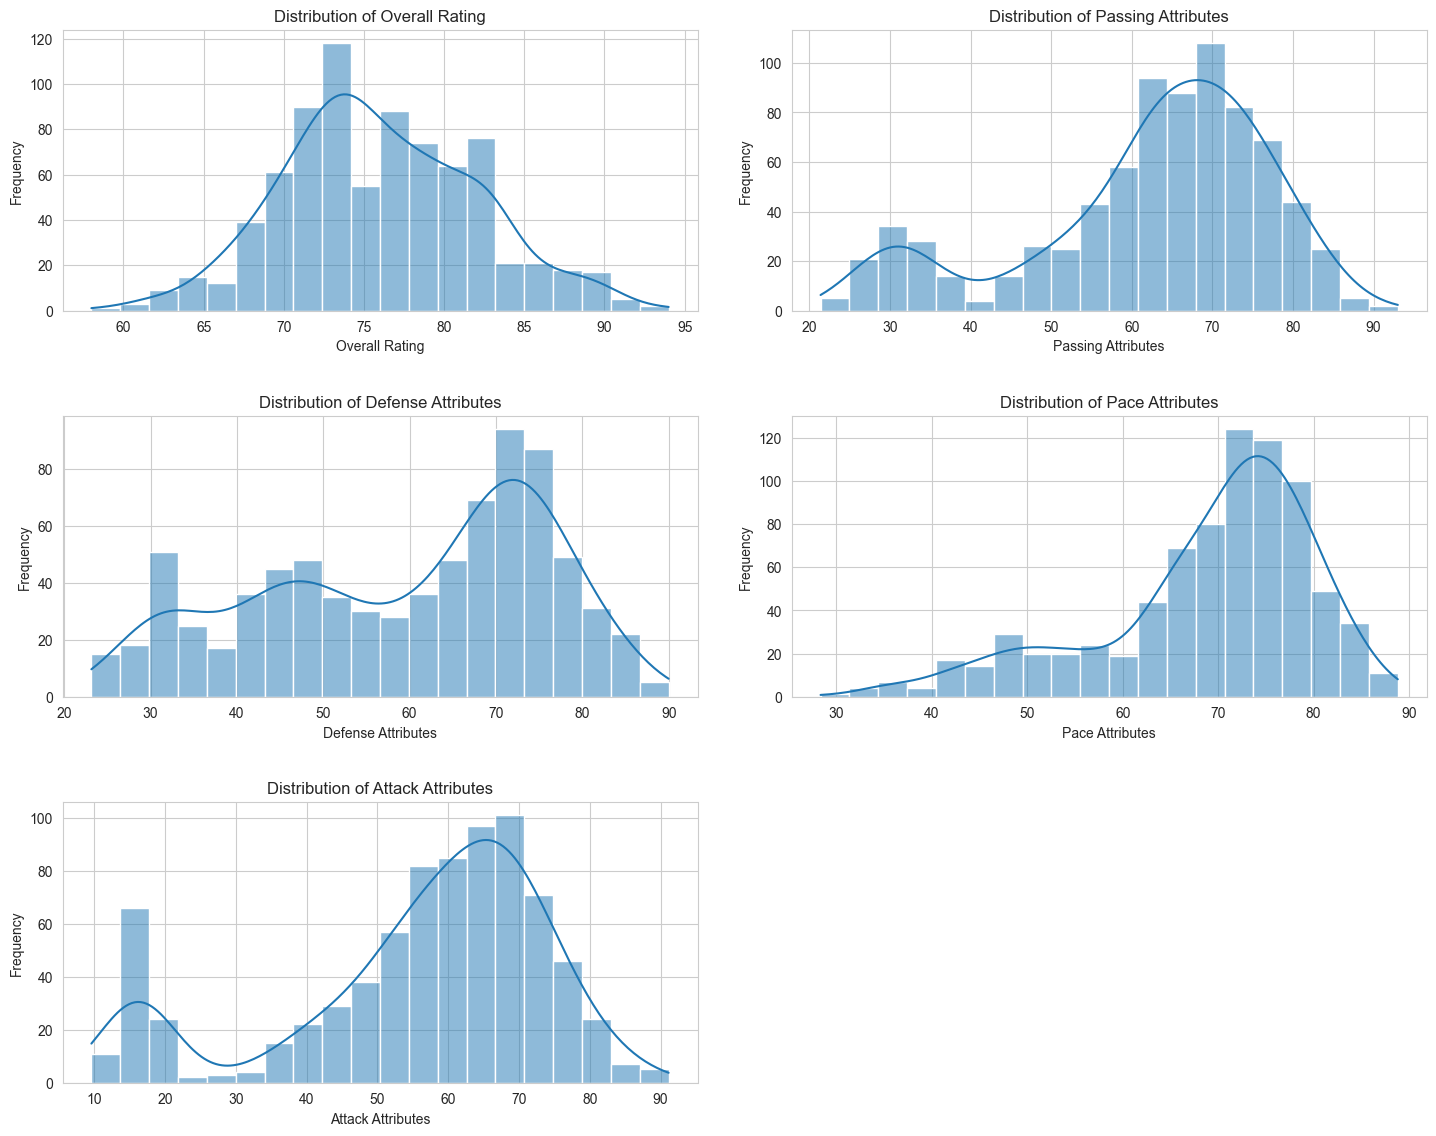

In [26]:
# show the distribution of overall_rating, passing_attributes, defence_attributes, attack_attributes, and pace_attributes.
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

sns.histplot(df['overall_rating'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Overall Rating')
axes[0, 0].set_xlabel('Overall Rating')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df['passing_attributes'], bins=20, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Passing Attributes')
axes[0, 1].set_xlabel('Passing Attributes')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(df['defense_attributes'], bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Defense Attributes')
axes[1, 0].set_xlabel('Defense Attributes')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(df['pace_attributes'], bins=20, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Pace Attributes')
axes[1, 1].set_xlabel('Pace Attributes')
axes[1, 1].set_ylabel('Frequency')

sns.histplot(df['attack_attributes'], bins=20, kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Distribution of Attack Attributes')
axes[2, 0].set_xlabel('Attack Attributes')
axes[2, 0].set_ylabel('Frequency')

axes[2, 1].set_visible(False)  # ← hides the empty 6th plot

plt.tight_layout(pad=3.0)  # ← fixes overlapping titles
plt.show()


### Overall Rating
The distribution of overall ratings appears approximately normal, centred around 73-75. 
The majority of players fall within the 65-85 range, with very few players 
achieving ratings above 90.

### Passing Attributes
The passing attributes distribution shows a bimodal pattern, with two peaks visible. 
This suggests two distinct groups of players with different passing abilities, 
with the main concentration sitting between 60-80.

### Defense Attributes
Defense attributes display a relatively flat, spread-out distribution ranging from 
20-90. This wide spread suggests a large variation in defensive ability across players, 
which is expected as not all players are required to defend.

### Pace Attributes
Pace attributes are heavily right-skewed, with most players clustered in the 
65-80 range. The long left tail indicates a smaller group of slower players.

### Attack Attributes
The attack attributes distribution is left-skewed, with most values concentrated 
between 50-80. Similar to defense, the spread reflects that attacking ability 
varies significantly by position.

## Summary
Across all five attributes, there is considerable variation in player abilities. 
Overall rating follows the most normal distribution, while positional attributes 
such as defense and attack show wider spreads, reflecting the diversity of 
player roles within the dataset.

Show core relationships between variables

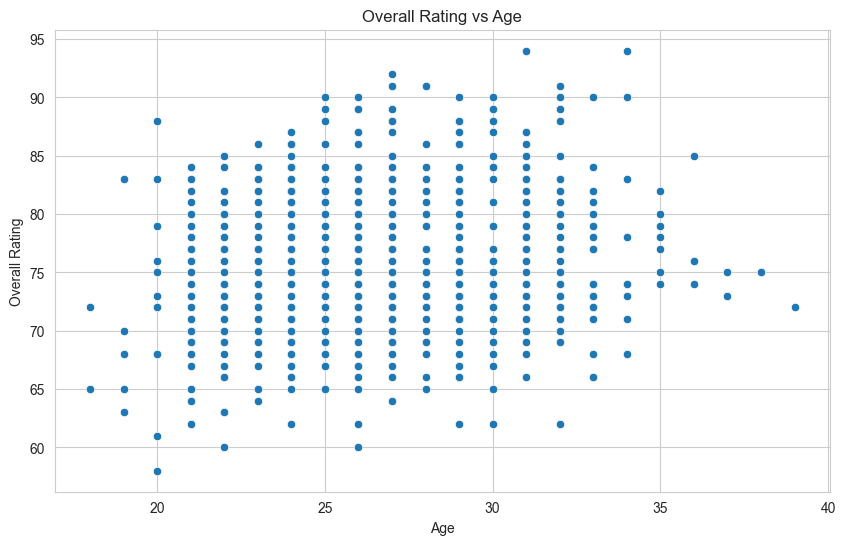

In [27]:
# show core relationships between overall_rating and age using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='overall_rating', data=df)
plt.title('Overall Rating vs Age')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.show()

## Overall Rating vs Age

The scatter plot reveals a general trend where younger players (under 20) and older 
players (above 35) tend to have lower overall ratings. Players aged 30-35 demonstrate 
the highest ratings, which aligns with expectations as these players have accumulated 
significant experience whilst still being in their physical prime. This suggests that 
peak performance in football is typically reached in the early-to-mid thirties.

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---